# Notebook Tuning & Evaluasi BERTopic vs LDA
## Analisis Evolusi Topik Riset Skripsi Informatika UNSOED

**Penulis:** Muhamad Galih (H1D022052)

Notebook ini melakukan:
1. **Preprocessing** — Dual-pipeline (cleaned_text untuk BERTopic, processed_text untuk LDA)
2. **Tuning** — 24 skenario BERTopic + 24 skenario LDA
3. **Evaluasi** — Formula unified `score_cv_td = 0.65 × Cv + 0.35 × TD` (apple-to-apple)
4. **Retrain** — Model terbaik di-retrain + simpan artefak
5. **DTA** — Dynamic Topic Analysis dengan threshold relative_slope = ±0.10
6. **Visualisasi** — WordCloud, distribusi topik, tren temporal

In [2]:
import itertools
import json
import math
import random
import sys
import time
import os
from collections import Counter
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from wordcloud import WordCloud
except Exception:
    WordCloud = None

from IPython.display import display

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Konfigurasi path lokal.
CWD = Path.cwd()

candidate_fastapi_roots = [
    CWD,
    CWD / "fastapi",
    CWD.parent,
    CWD.parent / "fastapi",
]

FASTAPI_ROOT = None
for candidate in candidate_fastapi_roots:
    if (candidate / "app").exists():
        FASTAPI_ROOT = candidate.resolve()
        break

if FASTAPI_ROOT is None:
    raise FileNotFoundError(
        "Folder FastAPI tidak ditemukan. Jalankan notebook dari root repo atau folder fastapi."
    )

DATA_RAW_DIR = FASTAPI_ROOT / "data" / "raw"
if not DATA_RAW_DIR.exists():
    raise FileNotFoundError(f"Folder data raw tidak ditemukan: {DATA_RAW_DIR}")

raw_csv_candidates = sorted(DATA_RAW_DIR.glob("*.csv"))
if not raw_csv_candidates:
    raise FileNotFoundError(f"Tidak ada file CSV pada folder: {DATA_RAW_DIR}")

# Pastikan import app.* terbaca.
if str(FASTAPI_ROOT) not in sys.path:
    sys.path.insert(0, str(FASTAPI_ROOT))

try:
    from app.ml.bertopic_trainer import BERTopicTrainer
    from app.ml.evaluator import TopicEvaluator
    from app.ml.lda_trainer import LDATrainer
    from app.models.schemas import (
        BERTopicHyperparameters,
        HDBSCANHyperparameters,
        LDAHyperparameters,
        UMAPHyperparameters,
    )
    from app.services.preprocessing import TextPreprocessor
except ImportError as exc:
    raise ImportError(
        f"Gagal import module FastAPI dari {FASTAPI_ROOT}. Pastikan dependency sudah terpasang."
    ) from exc

RUN_TS = datetime.now().strftime("%Y%m%d-%H%M%S")
ARTIFACT_ROOT = FASTAPI_ROOT / "data" / "results" / "notebook_tuning_web_form"
RUN_DIR = ARTIFACT_ROOT / f"run_{RUN_TS}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)

print("CWD:", CWD)
print("FASTAPI_ROOT:", FASTAPI_ROOT)
print("DATA_RAW_DIR:", DATA_RAW_DIR)
print("Raw CSV:", [p.name for p in raw_csv_candidates])
print("RUN_DIR:", RUN_DIR)
print("WordCloud available:", WordCloud is not None)

CWD: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/scripts
FASTAPI_ROOT: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi
DATA_RAW_DIR: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/raw
Raw CSV: ['combinations.csv', 'raw_data.csv']
RUN_DIR: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-220200
WordCloud available: True


## 2. Konfigurasi Parameter

### Kombinasi Skenario (Fixed)
Kombinasi 24 BERTopic + 24 LDA dimuat dari file CSV yang telah dikurasi sebelumnya, **bukan** di-generate ulang secara random. Ini memastikan reproduksibilitas 100%.

- `combinations.csv` → 24 BERTopic + 24 LDA (split berdasarkan kolom `model`)

### Formula Evaluasi (Unified — Apple-to-Apple)

Kedua model menggunakan formula **identik** untuk objective score:

$$S = 0.65 \times C_v + 0.35 \times TD$$

Dengan topic floor penalty untuk skenario yang kolaps (≤ 2 topik):

$$S = 0, \quad \text{jika jumlah topik} \leq 2$$

Composite score (leaderboard gabungan 48 skenario):

$$\text{composite} = 0.45 \times \hat{S} + 0.30 \times \hat{C}_v + 0.20 \times \hat{TD} + 0.05 \times \widehat{eff}$$

### DTA Threshold
- `DTA_TREND_THRESHOLD = 0.10` (10% dari baseline frekuensi rata-rata)

In [3]:
# ============================================================
# 2. Konfigurasi Parameter
# ============================================================


COMBINATIONS_CSV = FASTAPI_ROOT / "data" / "raw" / "combinations.csv"


WEB_FORM_BERTOPIC_BASE = {
    "embedding_model": "denaya/indoSBERT-large",
    "vectorizer_min_df": 2,
    "vectorizer_max_df": 0.95,
    "vectorizer_token_pattern": r"(?u)\b\w{3,}\b",
    "vectorizer_fallback_min_df": 1,
    "vectorizer_fallback_max_df": 1.0,
    "coherence_type": "c_v",
    "coherence_tokenization": "vectorizer",
    "coherence_dict_no_below": 3,
    "coherence_dict_no_above": 0.95,
    "reduce_outliers": True,
    "reduce_outliers_threshold_ctfidf": 0.10,
    "reduce_outliers_use_distributions": True,
    "reduce_outliers_threshold_distributions": 0.05,
    "use_mmr_representation": True,
    "mmr_diversity": 0.3,
    "embedding_batch_size": 16,
    "seed": 42,
}

WEB_FORM_LDA_BASE = {
    "random_state": 42,
}

# --- Evaluation config (UNIFIED — apple-to-apple) ---
SCORE_WEIGHT_CV  = 0.65   # bobot coherence dalam objective score
SCORE_WEIGHT_TD  = 0.35   # bobot diversity dalam objective score
MIN_TOPIC_FLOOR  = 2      # ≤ 2 topik → score = 0 (topic floor penalty)

# --- Composite score weights ---
W_OBJECTIVE  = 0.45
W_COHERENCE  = 0.30
W_DIVERSITY  = 0.20
W_EFFICIENCY = 0.05

# --- DTA config ---
DTA_TREND_THRESHOLD = 0.10  # 10% relative slope threshold
DTA_MIN_POINTS      = 3     # minimum 3 time slices untuk regresi

print(f"Scoring formula: S = {SCORE_WEIGHT_CV}×Cv + {SCORE_WEIGHT_TD}×TD")
print(f"Topic floor: score=0 jika topics ≤ {MIN_TOPIC_FLOOR}")
print(f"Composite weights: {W_OBJECTIVE}/{W_COHERENCE}/{W_DIVERSITY}/{W_EFFICIENCY}")
print(f"DTA threshold: ±{DTA_TREND_THRESHOLD}")
print(f"Combinations CSV: {COMBINATIONS_CSV}")

Scoring formula: S = 0.65×Cv + 0.35×TD
Topic floor: score=0 jika topics ≤ 2
Composite weights: 0.45/0.3/0.2/0.05
DTA threshold: ±0.1
Combinations CSV: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/raw/combinations.csv


## 3. Preprocessing (Dual-Pipeline)

- **Jalur BERTopic** → `cleaned_text` (kalimat natural, tanpa stemming)
- **Jalur LDA** → `processed_text` (token terstem, stopword removed)

> **Upload sebelum run:**
> - `raw_data.csv` → `/content/data/raw/`
> - `combinations.csv` → `/content/data/raw/`
> - Folder `app/` (source code FastAPI) → `/content/app/`

In [4]:
# ============================================================
# 3. Preprocessing
# ============================================================

preprocessor = TextPreprocessor(
    remove_stopwords=True,
    use_stemming=True,
    min_word_length=3,
    language="indonesian",
)

def _normalize_columns(df):
    """Normalisasi nama kolom ke format standar."""
    df = df.copy()
    rename = {}
    for col in df.columns:
        norm = str(col).strip().lower().replace("%", "pct")
        norm = "".join(ch if ch.isalnum() else "_" for ch in norm)
        while "__" in norm: norm = norm.replace("__", "_")
        rename[col] = norm.strip("_") or "col"
    df = df.rename(columns=rename)

    aliases = {
        "id": ["id", "skripsi_id"], "title": ["title", "judul"],
        "author": ["author", "penulis"], "year": ["year", "tahun"],
        "abstract": ["abstract", "abstrak"], "conclusion": ["conclusion", "kesimpulan"],
    }
    for target, candidates in aliases.items():
        if target not in df.columns:
            found = [c for c in candidates if c in df.columns]
            if found: df[target] = df[found[0]]
    if "id" not in df.columns:
        df["id"] = range(1, len(df) + 1)
    for col in ["title", "abstract", "conclusion"]:
        if col in df.columns:
            df[col] = df[col].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    return df

# Load data
raw_csv = FASTAPI_ROOT / "data" / "raw" / "raw_data.csv"
raw_df = _normalize_columns(pd.read_csv(raw_csv))
print(f"Raw data: {len(raw_df)} rows")

# Clean: drop null abstract, dedup
stage_df = raw_df.dropna(subset=["abstract"]).reset_index(drop=True)
stage_df = stage_df.drop_duplicates(subset=["abstract"]).reset_index(drop=True)
print(f"After dedup: {len(stage_df)} rows")

# Run preprocessing
preprocessed_df = preprocessor.preprocess_dataframe(stage_df, text_column="abstract")

# Validasi kolom
for col in ["cleaned_text", "processed_text"]:
    if col not in preprocessed_df.columns:
        raise ValueError(f"Kolom '{col}' tidak ditemukan setelah preprocessing")

# Filter baris kosong
mask = (
    preprocessed_df["cleaned_text"].str.strip().ne("")
    & preprocessed_df["processed_text"].str.strip().ne("")
)
preprocessed_df = preprocessed_df[mask].reset_index(drop=True)
print(f"Final corpus: {len(preprocessed_df)} documents")

# Siapkan input per model
bertopic_docs = preprocessed_df["cleaned_text"].tolist()
lda_docs      = preprocessed_df["processed_text"].tolist()
timestamps    = preprocessed_df["year"].tolist() if "year" in preprocessed_df.columns else None
document_ids  = preprocessed_df["id"].tolist() if "id" in preprocessed_df.columns else list(range(len(preprocessed_df)))

# Statistik token
before_after = preprocessed_df.copy()
before_after["token_cleaned"]   = before_after["cleaned_text"].str.split().str.len()
before_after["token_processed"] = before_after["processed_text"].str.split().str.len()

stats = before_after[["token_cleaned", "token_processed"]].describe().round(2)
print("\nStatistik token:")
display(stats)

# Simpan before/after
ba_path = RUN_DIR / "preprocessing_before_after.csv"
cols_save = [c for c in ["id", "title", "year", "cleaned_text", "processed_text",
                          "token_cleaned", "token_processed"] if c in before_after.columns]
before_after[cols_save].to_csv(ba_path, index=False)
print(f"Saved: {ba_path}")

2026-04-19 22:02:01.011 | INFO     | app.services.preprocessing:preprocess_dataframe:161 - Preprocessing 473 documents (dual pipeline)...
2026-04-19 22:02:01.012 | INFO     | app.services.preprocessing:preprocess_dataframe:175 -   Building combined_text (title + abstract + optional conclusion)...


Raw data: 474 rows
After dedup: 473 rows


2026-04-19 22:02:01.161 | INFO     | app.services.preprocessing:preprocess_dataframe:181 -   [BERTopic pipeline] Soft clean (no stopword removal, no stemming)...
2026-04-19 22:02:01.295 | INFO     | app.services.preprocessing:preprocess_dataframe:184 -   [LDA pipeline] Full clean + stopword removal + stemming...
2026-04-19 22:10:22.906 | INFO     | app.services.preprocessing:preprocess_dataframe:200 - Preprocessing complete. 473 documents remaining.
2026-04-19 22:10:23.073 | INFO     | app.services.preprocessing:preprocess_dataframe:201 -   cleaned_text avg words: 285.1
2026-04-19 22:10:23.081 | INFO     | app.services.preprocessing:preprocess_dataframe:204 -   processed_text avg words: 160.6


Final corpus: 473 documents

Statistik token:


,token_cleaned,token_processed
count,473.00,473.00
mean,285.06,160.56
std,125.86,74.34
min,71.00,39.00
25%,190.00,107.00
50%,270.00,146.00
75%,350.00,200.00
max,954.00,614.00


Saved: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-220200/preprocessing_before_after.csv


## 4. Loop Tuning (24 BERTopic + 24 LDA)

- **Kombinasi fixed** dari CSV kurasi (bukan random sampling)
- **BERTopic**: embedding dihitung SEKALI (`shared_embeddings`), dipakai ulang ke semua 24 skenario
- **LDA**: loop standar per skenario
- **DTA** tidak dihitung di loop tuning (hanya di tahap final) agar lebih cepat
- Formula evaluasi **UNIFIED**: `score_cv_td = 0.65 × Cv + 0.35 × TD`

In [5]:
# ============================================================
# 4. Tuning Loop (Fixed Combinations from CSV)
# ============================================================

# --- Helper functions ---
def normalize_nr_topics(value):
    if value is None: return None
    text = str(value).strip().lower()
    if text in {"", "none", "null"}: return None
    if text == "auto": return "auto"
    return int(float(text))

def compute_objective_score(cv, td, num_topics):
    """
    Formula UNIFIED untuk BERTopic dan LDA (apple-to-apple):
    S = 0.65 × Cv + 0.35 × TD
    Topic floor penalty: S = 0 jika topics ≤ 2
    """
    score = SCORE_WEIGHT_CV * float(cv or 0) + SCORE_WEIGHT_TD * float(td or 0)
    penalized = False
    try:
        if int(num_topics or 0) <= MIN_TOPIC_FLOOR:
            score = 0.0
            penalized = True
    except (TypeError, ValueError):
        pass
    return round(score, 6), penalized

def make_bertopic_params(combo):
    """Buat BERTopicHyperparameters dari dict combo CSV."""
    ngram = combo.get("n_gram_range", [1, 2])
    if isinstance(ngram, str):
        ngram = json.loads(ngram)

    return BERTopicHyperparameters(
        embedding_model=combo.get("embedding_model", WEB_FORM_BERTOPIC_BASE["embedding_model"]),
        min_topic_size=int(combo.get("min_topic_size", 10)),
        nr_topics=normalize_nr_topics(combo.get("nr_topics")),
        top_n_words=int(combo.get("top_n_words", 15)),
        n_gram_range=[int(ngram[0]), int(ngram[1])],
        vectorizer_min_df=int(combo.get("vectorizer_min_df", WEB_FORM_BERTOPIC_BASE["vectorizer_min_df"])),
        vectorizer_max_df=float(combo.get("vectorizer_max_df", WEB_FORM_BERTOPIC_BASE["vectorizer_max_df"])),
        vectorizer_token_pattern=combo.get("vectorizer_token_pattern", WEB_FORM_BERTOPIC_BASE["vectorizer_token_pattern"]),
        vectorizer_fallback_min_df=int(combo.get("vectorizer_fallback_min_df", WEB_FORM_BERTOPIC_BASE["vectorizer_fallback_min_df"])),
        vectorizer_fallback_max_df=float(combo.get("vectorizer_fallback_max_df", WEB_FORM_BERTOPIC_BASE["vectorizer_fallback_max_df"])),
        coherence_type=combo.get("coherence_type", WEB_FORM_BERTOPIC_BASE["coherence_type"]),
        coherence_tokenization=combo.get("coherence_tokenization", WEB_FORM_BERTOPIC_BASE["coherence_tokenization"]),
        coherence_dict_no_below=int(combo.get("coherence_dict_no_below", WEB_FORM_BERTOPIC_BASE["coherence_dict_no_below"])),
        coherence_dict_no_above=float(combo.get("coherence_dict_no_above", WEB_FORM_BERTOPIC_BASE["coherence_dict_no_above"])),
        reduce_outliers=bool(combo.get("reduce_outliers", WEB_FORM_BERTOPIC_BASE["reduce_outliers"])),
        reduce_outliers_threshold_ctfidf=float(combo.get("reduce_outliers_threshold_ctfidf", WEB_FORM_BERTOPIC_BASE["reduce_outliers_threshold_ctfidf"])),
        reduce_outliers_use_distributions=bool(combo.get("reduce_outliers_use_distributions", WEB_FORM_BERTOPIC_BASE["reduce_outliers_use_distributions"])),
        reduce_outliers_threshold_distributions=float(combo.get("reduce_outliers_threshold_distributions", WEB_FORM_BERTOPIC_BASE["reduce_outliers_threshold_distributions"])),
        use_mmr_representation=bool(combo.get("use_mmr_representation", WEB_FORM_BERTOPIC_BASE["use_mmr_representation"])),
        mmr_diversity=float(combo.get("mmr_diversity", WEB_FORM_BERTOPIC_BASE["mmr_diversity"])),
        embedding_batch_size=int(combo.get("embedding_batch_size", WEB_FORM_BERTOPIC_BASE["embedding_batch_size"])),
        seed=int(combo.get("seed", WEB_FORM_BERTOPIC_BASE["seed"])),
        umap_params=UMAPHyperparameters(
            n_neighbors=int(combo.get("umap_n_neighbors", 30)),
            n_components=int(combo.get("umap_n_components", 5)),
            min_dist=float(combo.get("umap_min_dist", 0.0)),
            metric=str(combo.get("umap_metric", "cosine")),
            random_state=int(combo.get("umap_random_state", 42)),
        ),
        hdbscan_params=HDBSCANHyperparameters(
            min_cluster_size=int(combo.get("hdbscan_min_cluster_size", 10)),
            min_samples=int(combo.get("hdbscan_min_samples", 1)),
            metric=str(combo.get("hdbscan_metric", "euclidean")),
            cluster_selection_method=str(combo.get("hdbscan_cluster_selection_method", "eom")),
        ),
    )

def make_lda_params(combo):
    """Buat LDAHyperparameters dari dict combo CSV."""
    eta_val = combo.get("eta")
    if isinstance(eta_val, str) and eta_val.lower() in ("none", "null", ""):
        eta_val = None
    elif isinstance(eta_val, float) and pd.isna(eta_val):
        eta_val = None

    return LDAHyperparameters(
        num_topics=int(combo["num_topics"]),
        passes=int(combo["passes"]),
        iterations=int(combo["iterations"]),
        chunksize=int(combo["chunksize"]),
        random_state=int(combo.get("random_state", 42)),
        alpha=combo["alpha"],
        eta=eta_val,
        no_below=int(combo["no_below"]),
        no_above=float(combo["no_above"]),
    )

# ============================================================
# LOAD FIXED COMBINATIONS FROM CSV
# ============================================================
print("📂 Loading fixed combinations from CSV...")

all_combos_csv = pd.read_csv(COMBINATIONS_CSV)
required_cols = {"model", "combo"}
if not required_cols.issubset(all_combos_csv.columns):
    raise ValueError(f"Kolom wajib tidak lengkap pada combinations.csv: {required_cols}")

all_combos_csv["model_norm"] = all_combos_csv["model"].astype(str).str.strip().str.lower()

bt_combos_raw = all_combos_csv.loc[all_combos_csv["model_norm"] == "bertopic", "combo"].dropna().tolist()
lda_combos_raw = all_combos_csv.loc[all_combos_csv["model_norm"] == "lda", "combo"].dropna().tolist()

bt_combos = [json.loads(c) for c in bt_combos_raw]
lda_combos = [json.loads(c) for c in lda_combos_raw]

if not bt_combos or not lda_combos:
    raise ValueError("Data kombinasi BERTopic/LDA tidak ditemukan di combinations.csv")

print(f"✅ BERTopic: {len(bt_combos)} kombinasi (fixed)")
print(f"✅ LDA: {len(lda_combos)} kombinasi (fixed)")

# Build scenarios
bt_scenarios = [{"scenario_id": f"bertopic_{i:03d}", "combo": c, "params": make_bertopic_params(c)}
                for i, c in enumerate(bt_combos, 1)]
lda_scenarios = [{"scenario_id": f"lda_{i:03d}", "combo": c, "params": make_lda_params(c)}
                 for i, c in enumerate(lda_combos, 1)]

# Simpan skenario
scenario_rows = (
    [{"model": "BERTopic", "scenario_id": s["scenario_id"],
      "combo": json.dumps(s["combo"], ensure_ascii=False)} for s in bt_scenarios]
    + [{"model": "LDA", "scenario_id": s["scenario_id"],
        "combo": json.dumps(s["combo"], ensure_ascii=False)} for s in lda_scenarios]
)
pd.DataFrame(scenario_rows).to_csv(RUN_DIR / "scenario_space.csv", index=False)
print(f"Total: {len(bt_scenarios) + len(lda_scenarios)} skenario")

# ============================
# 4a. LOOP BERTOPIC
# ============================
evaluator = TopicEvaluator()

# Compute embeddings ONCE
print("\n🔄 Computing shared embeddings...")
emb_trainer = BERTopicTrainer(params=bt_scenarios[0]["params"])
shared_embeddings = emb_trainer.compute_embeddings(bertopic_docs)
np.save(RUN_DIR / "shared_embeddings.npy", shared_embeddings)
print(f"✅ Shared embeddings: {shared_embeddings.shape}")

bt_rows = []
bt_payloads = []

for idx, sc in enumerate(bt_scenarios, 1):
    print(f"\n[BERTopic {idx}/{len(bt_scenarios)}] {sc['scenario_id']}")
    row = {"model": "BERTopic", "scenario_id": sc["scenario_id"], "status": "ok"}

    try:
        trainer = BERTopicTrainer(params=sc["params"])
        result = trainer.train(
            documents=bertopic_docs,
            embeddings=shared_embeddings,
            timestamps=None,
            document_ids=document_ids,
        )
        metrics = evaluator.evaluate_bertopic(
            model=trainer.model, documents=bertopic_docs,
            topics=trainer.topics, vectorizer_model=trainer.vectorizer_model,
            coherence_type=trainer.params.coherence_type,
            coherence_tokenization=trainer.params.coherence_tokenization,
            coherence_dict_no_below=trainer.params.coherence_dict_no_below,
            coherence_dict_no_above=trainer.params.coherence_dict_no_above,
            top_n_words=trainer.params.top_n_words,
        )

        num_topics = metrics.get("num_topics", result.get("num_topics"))
        cv = metrics.get("coherence_cv", 0)
        td = metrics.get("topic_diversity", 0)
        obj_score, penalized = compute_objective_score(cv, td, num_topics)

        row.update({
            "coherence_cv": cv, "topic_diversity": td,
            "num_topics": num_topics,
            "outlier_pct": metrics.get("outlier_pct", 0),
            "objective_score": obj_score,
            "topic_floor_penalized": penalized,
            "runtime_seconds": result.get("training_duration_seconds"),
            "params_json": json.dumps(sc["params"].model_dump(), ensure_ascii=False),
        })
        bt_payloads.append({
            "scenario": sc, "trainer": trainer,
            "result": result, "metrics": metrics,
            "objective_score": obj_score,
        })
        print(f"   Cv={cv:.4f}  TD={td:.4f}  Topics={num_topics}  S={obj_score:.4f}")

    except Exception as e:
        row.update({"status": "failed", "error": str(e),
                     "params_json": json.dumps(sc["params"].model_dump(), ensure_ascii=False)})
        print(f"   ❌ FAILED: {e}")

    bt_rows.append(row)

bt_df = pd.DataFrame(bt_rows)
bt_df = bt_df.sort_values("objective_score", ascending=False, na_position="last").reset_index(drop=True)
bt_df.to_csv(RUN_DIR / "bertopic_tuning_results.csv", index=False)

# ============================
# 4b. LOOP LDA
# ============================
lda_rows = []
lda_payloads = []

for idx, sc in enumerate(lda_scenarios, 1):
    print(f"\n[LDA {idx}/{len(lda_scenarios)}] {sc['scenario_id']}")
    row = {"model": "LDA", "scenario_id": sc["scenario_id"], "status": "ok"}

    try:
        trainer = LDATrainer(params=sc["params"])
        result = trainer.train(documents=lda_docs, timestamps=None)
        metrics = evaluator.evaluate_lda(
            model=trainer.model,
            tokenized_docs=trainer.tokenized_docs,
            dictionary=trainer.dictionary,
        )

        num_topics = metrics.get("num_topics", result.get("num_topics"))
        cv = metrics.get("coherence_cv", 0)
        td = metrics.get("topic_diversity", 0)
        obj_score, penalized = compute_objective_score(cv, td, num_topics)

        row.update({
            "coherence_cv": cv, "topic_diversity": td,
            "num_topics": num_topics,
            "objective_score": obj_score,
            "topic_floor_penalized": penalized,
            "runtime_seconds": result.get("training_duration_seconds"),
            "params_json": json.dumps(sc["params"].model_dump(), ensure_ascii=False),
        })
        lda_payloads.append({
            "scenario": sc, "trainer": trainer,
            "result": result, "metrics": metrics,
            "objective_score": obj_score,
        })
        print(f"   Cv={cv:.4f}  TD={td:.4f}  Topics={num_topics}  S={obj_score:.4f}")

    except Exception as e:
        row.update({"status": "failed", "error": str(e),
                     "params_json": json.dumps(sc["params"].model_dump(), ensure_ascii=False)})
        print(f"   ❌ FAILED: {e}")

    lda_rows.append(row)

lda_df = pd.DataFrame(lda_rows)
lda_df = lda_df.sort_values("objective_score", ascending=False, na_position="last").reset_index(drop=True)
lda_df.to_csv(RUN_DIR / "lda_tuning_results.csv", index=False)

print(f"\n✅ BERTopic: {len(bt_df)} rows, LDA: {len(lda_df)} rows")
if "topic_floor_penalized" in bt_df.columns:
    print(f"BERTopic penalized (≤{MIN_TOPIC_FLOOR} topics): {bt_df['topic_floor_penalized'].fillna(False).sum()}")

📂 Loading fixed combinations from CSV...
✅ BERTopic: 24 kombinasi (fixed)
✅ LDA: 24 kombinasi (fixed)


2026-04-19 22:10:23.502 | INFO     | app.ml.bertopic_trainer:compute_embeddings:335 - Computing sentence embeddings for 473 documents using denaya/indoSBERT-large...
2026-04-19 22:10:23.503 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:175 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)


Total: 48 skenario

🔄 Computing shared embeddings...


Batches: 100%|██████████| 30/30 [08:05<00:00, 16.20s/it]
2026-04-19 22:18:37.772 | INFO     | app.ml.bertopic_trainer:compute_embeddings:368 - Embeddings shape: (473, 256) (dim=256)
2026-04-19 22:18:37.785 | INFO     | app.ml.bertopic_trainer:train:390 - Starting BERTopic training on 473 documents
2026-04-19 22:18:37.786 | INFO     | app.ml.bertopic_trainer:train:391 - Embedding model: denaya/indoSBERT-large (256-dim)


✅ Shared embeddings: (473, 256)

[BERTopic 1/24] bertopic_001


...

   Cv=0.3484  TD=0.4625  Topics=8  S=0.3883

[LDA 23/24] lda_023


2026-04-19 23:02:30.158 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 6.78s
2026-04-19 23:02:30.160 | INFO     | app.ml.evaluator:compute_coherence_gensim:48 - Computing c_v coherence for LDA...
2026-04-19 23:02:31.240 | INFO     | app.ml.evaluator:compute_coherence_gensim:58 - LDA Coherence (c_v): 0.3588
2026-04-19 23:02:31.243 | INFO     | app.ml.evaluator:compute_topic_diversity:135 - Topic Diversity: 0.4938 (79 unique / 160 total words)
2026-04-19 23:02:31.244 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents
2026-04-19 23:02:31.293 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 1435 unique tokens (after filtering: no_below=4, no_above=0.95)
2026-04-19 23:02:31.315 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-19 23:02:31.316 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 10 topics, 10 passes (model: LdaModel deterministic, alpha=0.1, eta=0.1)...

   Cv=0.3588  TD=0.4938  Topics=16  S=0.4061

[LDA 24/24] lda_024


2026-04-19 23:02:39.229 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 7.99s
2026-04-19 23:02:39.232 | INFO     | app.ml.evaluator:compute_coherence_gensim:48 - Computing c_v coherence for LDA...
2026-04-19 23:02:40.410 | INFO     | app.ml.evaluator:compute_coherence_gensim:58 - LDA Coherence (c_v): 0.3848
2026-04-19 23:02:40.413 | INFO     | app.ml.evaluator:compute_topic_diversity:135 - Topic Diversity: 0.5200 (52 unique / 100 total words)


   Cv=0.3848  TD=0.5200  Topics=10  S=0.4321

✅ BERTopic: 24 rows, LDA: 24 rows
BERTopic penalized (≤2 topics): 6


## 5. Composite Score Leaderboard (48 Skenario)

Normalisasi min-max terhadap seluruh 48 skenario, kemudian hitung composite score:

$$\text{composite} = 0.45 \times \hat{S} + 0.30 \times \hat{C}_v + 0.20 \times \hat{TD} + 0.05 \times \widehat{eff}$$

In [6]:
# ============================================================
# 5. Composite Score Leaderboard
# ============================================================

def _minmax(series):
    vals = pd.to_numeric(series, errors="coerce")
    vmin, vmax = vals.min(), vals.max()
    if pd.isna(vmin) or pd.isna(vmax) or vmin == vmax:
        return pd.Series(0.5, index=vals.index)
    return (vals - vmin) / (vmax - vmin)

# Gabungkan hasil BERTopic dan LDA
lb_rows = []
for df_src in [bt_df, lda_df]:
    ok = df_src[df_src["status"] == "ok"].copy()
    for _, r in ok.iterrows():
        lb_rows.append({
            "model": r.get("model"),
            "scenario_id": r.get("scenario_id"),
            "objective_score": r.get("objective_score"),
            "coherence_cv": r.get("coherence_cv"),
            "topic_diversity": r.get("topic_diversity"),
            "num_topics": r.get("num_topics"),
            "runtime_seconds": r.get("runtime_seconds"),
        })

leaderboard = pd.DataFrame(lb_rows)

if not leaderboard.empty:
    # Normalisasi min-max
    leaderboard["objective_norm"]  = _minmax(leaderboard["objective_score"])
    leaderboard["coherence_norm"]  = _minmax(leaderboard["coherence_cv"])
    leaderboard["diversity_norm"]  = _minmax(leaderboard["topic_diversity"])
    leaderboard["efficiency_norm"] = 1 - _minmax(leaderboard["runtime_seconds"])

    # Composite score
    leaderboard["composite_score"] = (
        W_OBJECTIVE  * leaderboard["objective_norm"]
        + W_COHERENCE  * leaderboard["coherence_norm"]
        + W_DIVERSITY  * leaderboard["diversity_norm"]
        + W_EFFICIENCY * leaderboard["efficiency_norm"]
    ).round(6)

    leaderboard = leaderboard.sort_values(
        ["composite_score", "objective_score", "coherence_cv"],
        ascending=[False, False, False], na_position="last"
    ).reset_index(drop=True)
    leaderboard["rank"] = range(1, len(leaderboard) + 1)

# Simpan
lb_path = RUN_DIR / "leaderboard_composite.csv"
leaderboard.to_csv(lb_path, index=False)

print("🏆 Top-10 Leaderboard:")
display(leaderboard.head(10))
print(f"\nSaved: {lb_path}")

🏆 Top-10 Leaderboard:


,model,scenario_id,objective_score,coherence_cv,topic_diversity,num_topics,runtime_seconds,objective_norm,coherence_norm,diversity_norm,efficiency_norm,composite_score,rank
0,BERTopic,bertopic_017,0.632755,0.5182,0.8455,11,118.61,1.000000,0.686441,0.785219,0.471672,0.836560,1
1,BERTopic,bertopic_006,0.623025,0.4685,0.9100,10,81.83,0.984623,0.517966,0.909353,0.644032,0.812542,2
2,BERTopic,bertopic_010,0.624530,0.4608,0.9286,7,103.67,0.987001,0.491864,0.945150,0.541684,0.807824,3
3,BERTopic,bertopic_021,0.608705,0.4399,0.9222,9,114.70,0.961992,0.421017,0.932833,0.489995,0.770268,4
4,BERTopic,bertopic_015,0.605840,0.4167,0.9571,7,87.82,0.957464,0.342373,1.000000,0.615961,0.764369,5
5,BERTopic,bertopic_019,0.603665,0.4441,0.9000,11,107.40,0.954026,0.435254,0.890108,0.524205,0.764120,6
6,BERTopic,bertopic_004,0.593100,0.4398,0.8778,9,114.99,0.937330,0.420678,0.847383,0.488636,0.741910,7
7,BERTopic,bertopic_007,0.591380,0.4301,0.8909,11,107.32,0.934611,0.387797,0.872594,0.524579,0.737662,8
8,BERTopic,bertopic_013,0.589105,0.4364,0.8727,11,99.46,0.931016,0.409153,0.837567,0.561413,0.737287,9
9,BERTopic,bertopic_014,0.587805,0.4197,0.9000,12,75.47,0.928961,0.352542,0.890108,0.673837,0.735509,10



Saved: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-220200/leaderboard_composite.csv


## 6. Retrain Best Model + Simpan Artefak

Retrain model terbaik dari masing-masing algoritma, lalu simpan:
- Model file (safetensors / gensim)
- Topic keywords CSV
- Best config JSON

In [7]:
# ============================================================
# 6. Retrain Best Model
# ============================================================

def to_serializable(obj):
    if isinstance(obj, dict): return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [to_serializable(v) for v in obj]
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj

def write_json(path, payload):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(to_serializable(payload), f, ensure_ascii=False, indent=2)

def save_bertopic(trainer, job_id):
    try:
        return trainer.save_model(job_id)
    except PermissionError:
        d = RUN_DIR / "saved_models" / f"bertopic_{job_id}"
        d.mkdir(parents=True, exist_ok=True)
        trainer.model.save(str(d / "model"), serialization="safetensors", save_ctfidf=True)
        if getattr(trainer, "embeddings", None) is not None:
            np.save(str(d / "embeddings.npy"), trainer.embeddings)
        return str(d)

def save_lda(trainer, job_id):
    try:
        return trainer.save_model(job_id)
    except PermissionError:
        d = RUN_DIR / "saved_models" / f"lda_{job_id}"
        d.mkdir(parents=True, exist_ok=True)
        trainer.model.save(str(d / "lda_model"))
        trainer.dictionary.save(str(d / "dictionary.dict"))
        return str(d)

# --- Select best ---
best_bt = max(bt_payloads, key=lambda x: x["objective_score"]) if bt_payloads else None
best_lda = max(lda_payloads, key=lambda x: x["objective_score"]) if lda_payloads else None

final_bertopic = None
final_lda = None

# --- Retrain BERTopic ---
if best_bt:
    print(f"🔄 Retrain BERTopic: {best_bt['scenario']['scenario_id']}")
    params = best_bt["scenario"]["params"]
    trainer = BERTopicTrainer(params=params)
    result = trainer.train(documents=bertopic_docs, embeddings=shared_embeddings,
                           timestamps=None, document_ids=document_ids)
    metrics = evaluator.evaluate_bertopic(
        model=trainer.model, documents=bertopic_docs, topics=trainer.topics,
        vectorizer_model=trainer.vectorizer_model,
        coherence_type=trainer.params.coherence_type,
        coherence_tokenization=trainer.params.coherence_tokenization,
        coherence_dict_no_below=trainer.params.coherence_dict_no_below,
        coherence_dict_no_above=trainer.params.coherence_dict_no_above,
        top_n_words=trainer.params.top_n_words,
    )
    path = save_bertopic(trainer, f"best_bt_{RUN_TS}")
    final_bertopic = {"trainer": trainer, "params": params, "result": result,
                      "metrics": metrics, "path": path,
                      "scenario_id": best_bt["scenario"]["scenario_id"]}
    print(f"   ✅ Cv={metrics.get('coherence_cv')}, TD={metrics.get('topic_diversity')}, Topics={metrics.get('num_topics')}")

# --- Retrain LDA ---
if best_lda:
    print(f"🔄 Retrain LDA: {best_lda['scenario']['scenario_id']}")
    params = best_lda["scenario"]["params"]
    trainer = LDATrainer(params=params)
    result = trainer.train(documents=lda_docs)
    metrics = evaluator.evaluate_lda(model=trainer.model,
                                      tokenized_docs=trainer.tokenized_docs,
                                      dictionary=trainer.dictionary)
    path = save_lda(trainer, f"best_lda_{RUN_TS}")
    final_lda = {"trainer": trainer, "params": params, "result": result,
                 "metrics": metrics, "path": path,
                 "scenario_id": best_lda["scenario"]["scenario_id"]}
    print(f"   ✅ Cv={metrics.get('coherence_cv')}, TD={metrics.get('topic_diversity')}, Topics={metrics.get('num_topics')}")

# --- Export topic keywords ---
kw_frames = []

if final_bertopic:
    b_model = final_bertopic["trainer"].model
    b_info = b_model.get_topic_info()
    count_map = {int(r.Topic): int(r.Count) for _, r in b_info.iterrows() if int(r.Topic) != -1}

    rows = []
    for tid, ws in (b_model.get_topics() or {}).items():
        if int(tid) == -1: continue
        for rank, (word, score) in enumerate((ws or [])[:15], 1):
            rows.append({"model": "BERTopic", "topic_id": int(tid),
                         "doc_count": count_map.get(int(tid), 0),
                         "keyword_rank": rank, "keyword": word,
                         "keyword_score": round(float(score or 0), 6)})
    bt_kw = pd.DataFrame(rows)
    bt_kw.to_csv(RUN_DIR / "bertopic_topic_keywords.csv", index=False)
    kw_frames.append(bt_kw)

if final_lda:
    l_model = final_lda["trainer"].model
    l_dict = final_lda["trainer"].dictionary
    # Count dominant topics
    bows = [l_dict.doc2bow(str(d).split()) for d in lda_docs]
    dom_ids = []
    for bow in bows:
        if bow:
            dist = l_model.get_document_topics(bow, minimum_probability=0.0)
            if dist: dom_ids.append(int(max(dist, key=lambda x: x[1])[0]))
    count_map = dict(Counter(dom_ids))

    rows = []
    for tid in range(l_model.num_topics):
        for rank, (word, score) in enumerate(l_model.show_topic(tid, topn=15), 1):
            rows.append({"model": "LDA", "topic_id": tid,
                         "doc_count": count_map.get(tid, 0),
                         "keyword_rank": rank, "keyword": word,
                         "keyword_score": round(float(score or 0), 6)})
    lda_kw = pd.DataFrame(rows)
    lda_kw.to_csv(RUN_DIR / "lda_topic_keywords.csv", index=False)
    kw_frames.append(lda_kw)

if kw_frames:
    combined_kw = pd.concat(kw_frames, ignore_index=True)
    combined_kw.to_csv(RUN_DIR / "topic_keywords_combined.csv", index=False)

# --- Final metrics CSV ---
metrics_rows = []
if final_bertopic:
    m = final_bertopic["metrics"]
    metrics_rows.append({"model": "BERTopic", "scenario_id": final_bertopic["scenario_id"],
                         "coherence_cv": m.get("coherence_cv"), "topic_diversity": m.get("topic_diversity"),
                         "num_topics": m.get("num_topics")})
if final_lda:
    m = final_lda["metrics"]
    metrics_rows.append({"model": "LDA", "scenario_id": final_lda["scenario_id"],
                         "coherence_cv": m.get("coherence_cv"), "topic_diversity": m.get("topic_diversity"),
                         "num_topics": m.get("num_topics")})

final_metrics = pd.DataFrame(metrics_rows)
final_metrics.to_csv(RUN_DIR / "best_retrain_metrics.csv", index=False)

# --- Best config JSON ---
best_config = {"timestamp": RUN_TS, "scoring_formula": f"{SCORE_WEIGHT_CV}*Cv + {SCORE_WEIGHT_TD}*TD",
               "dta_threshold": DTA_TREND_THRESHOLD}
if final_bertopic:
    best_config["best_bertopic"] = {"scenario_id": final_bertopic["scenario_id"],
                                     "params": final_bertopic["params"].model_dump(),
                                     "metrics": final_bertopic["metrics"]}
if final_lda:
    best_config["best_lda"] = {"scenario_id": final_lda["scenario_id"],
                                "params": final_lda["params"].model_dump(),
                                "metrics": final_lda["metrics"]}
write_json(RUN_DIR / "best_config.json", best_config)

display(final_metrics)
print("\n✅ Retrain selesai. Artefak tersimpan.")

2026-04-19 23:02:40.618 | INFO     | app.ml.bertopic_trainer:train:390 - Starting BERTopic training on 473 documents
2026-04-19 23:02:40.619 | INFO     | app.ml.bertopic_trainer:train:391 - Embedding model: denaya/indoSBERT-large (256-dim)


🔄 Retrain BERTopic: bertopic_017


2026-04-19 23:02:40.909 | INFO     | app.ml.bertopic_trainer:train:394 - Reproducibility settings applied with seed=42
2026-04-19 23:02:40.911 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:175 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)
2026-04-19 23:02:54.477 | INFO     | app.ml.bertopic_trainer:_build_model:324 - BERTopic model pipeline built successfully
2026-04-19 23:02:54.491 | INFO     | app.ml.bertopic_trainer:train:404 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-19 23:02:54,513 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-19 23:02:57,119 - BERTopic - Dimensionality - Completed ✓
2026-04-19 23:02:57,121 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-19 23:02:57,179 - BERTopic - Cluster - Completed ✓
2026-04-19 23:02:57,180 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-0

   ✅ Cv=0.5182, TD=0.8455, Topics=11
🔄 Retrain LDA: lda_004


2026-04-19 23:05:05.208 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 12.44s
2026-04-19 23:05:05.397 | INFO     | app.ml.evaluator:compute_coherence_gensim:48 - Computing c_v coherence for LDA...
2026-04-19 23:05:06.227 | INFO     | app.ml.evaluator:compute_coherence_gensim:58 - LDA Coherence (c_v): 0.3583
2026-04-19 23:05:06.229 | INFO     | app.ml.evaluator:compute_topic_diversity:135 - Topic Diversity: 0.6500 (52 unique / 80 total words)


   ✅ Cv=0.3583, TD=0.65, Topics=8


,model,scenario_id,coherence_cv,topic_diversity,num_topics
0,BERTopic,bertopic_017,0.5182,0.8455,11
1,LDA,lda_004,0.3583,0.6500,8



✅ Retrain selesai. Artefak tersimpan.


## 7. Visualisasi

- Distribusi dokumen per topik (bar chart)
- WordCloud per topik (top 8)
- Perbandingan metrik BERTopic vs LDA

=== BERTopic ===


,Topic,Count,Name
0,0,84,0_desa_berbasis web_umkm_rancang bangun
1,1,90,1_unsoed_perancangan_audit_laporan
2,2,64,2_penjualan_transaksi_sampah_waterfall
3,3,29,3_performa_laravel_server_beban
4,4,55,4_deteksi_cnn_performa_precision
5,5,34,5_pendukung keputusan_penilaian_kriteria_simpl...
6,6,24,6_edukasi_siswa_pembelajaran_permainan
7,7,30,7_klasterisasi_klasifikasi_umkm_hama
8,8,25,8_produk_clustering_penjualan_rekomendasi
9,9,18,9_pmks_berbasis web_banjarnegara_rancang bangun


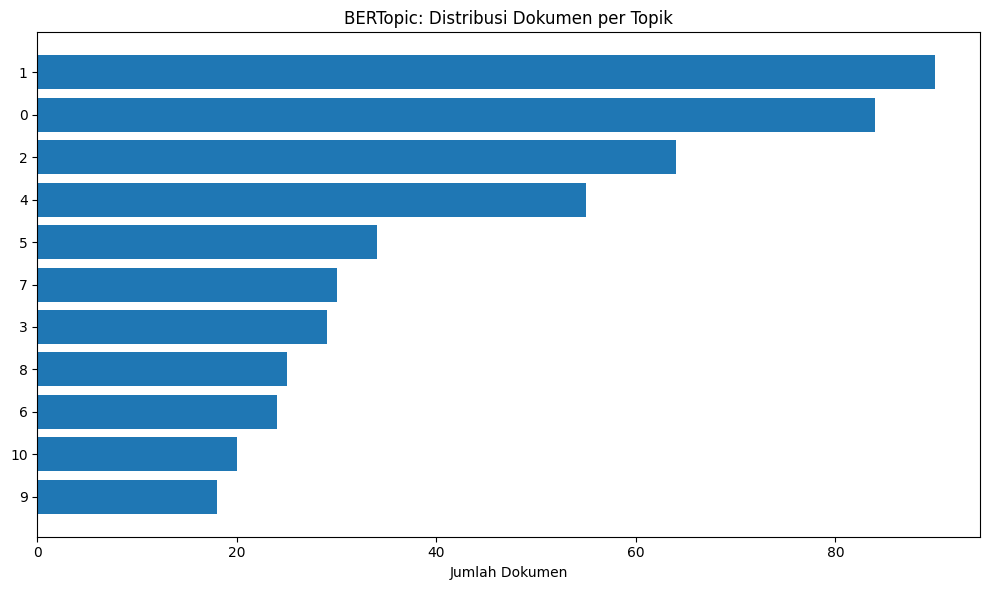

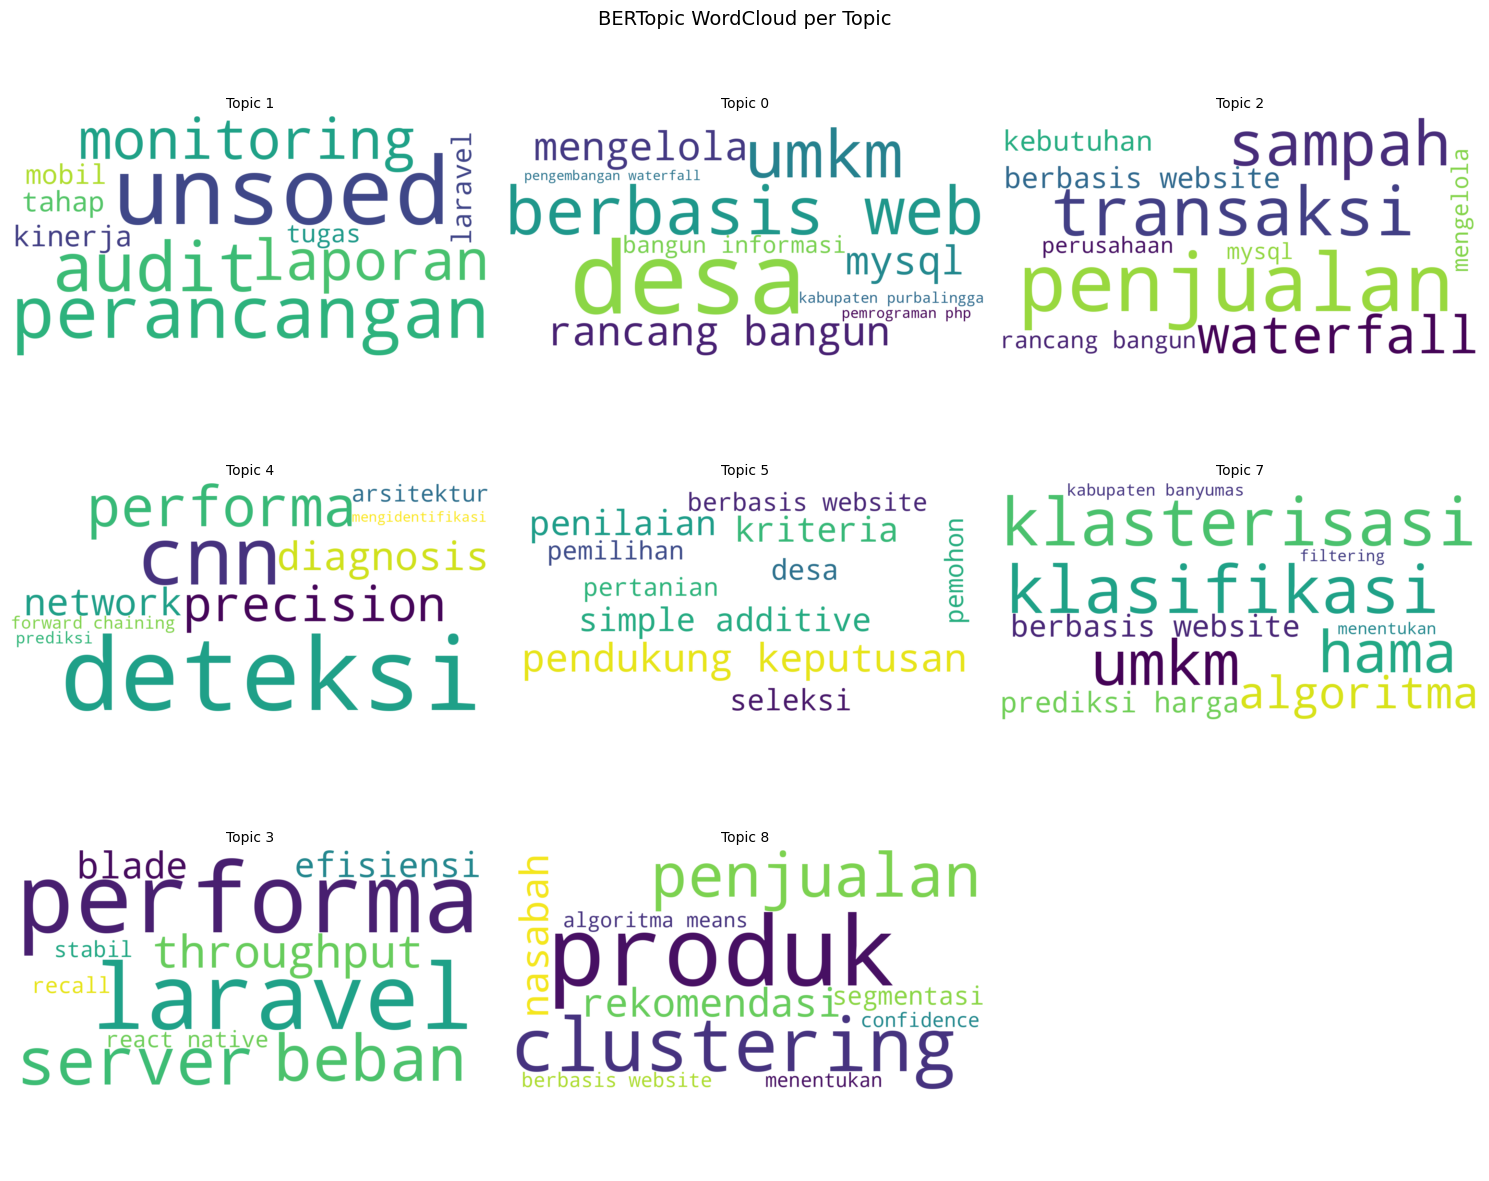


=== LDA ===


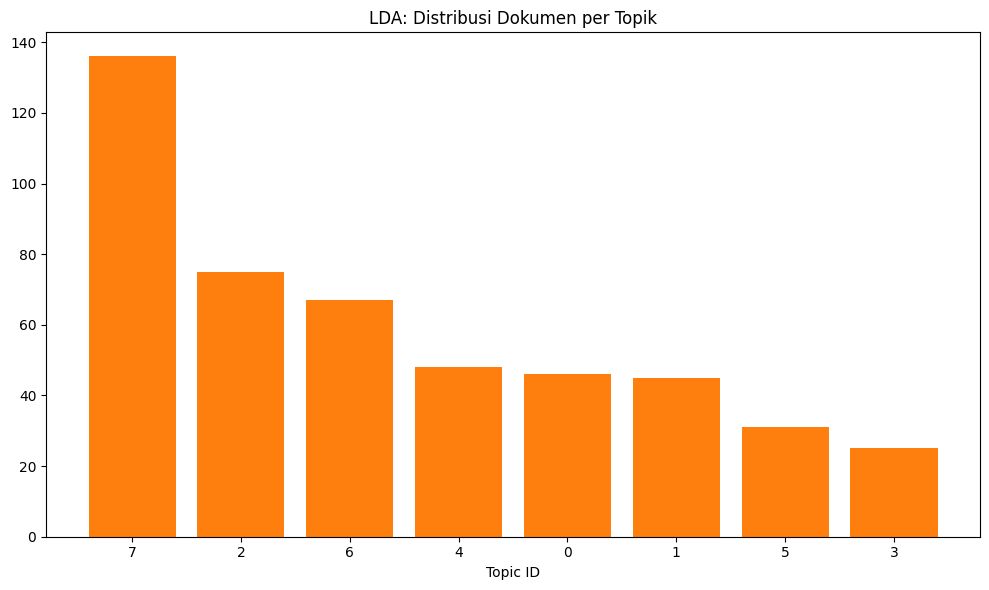

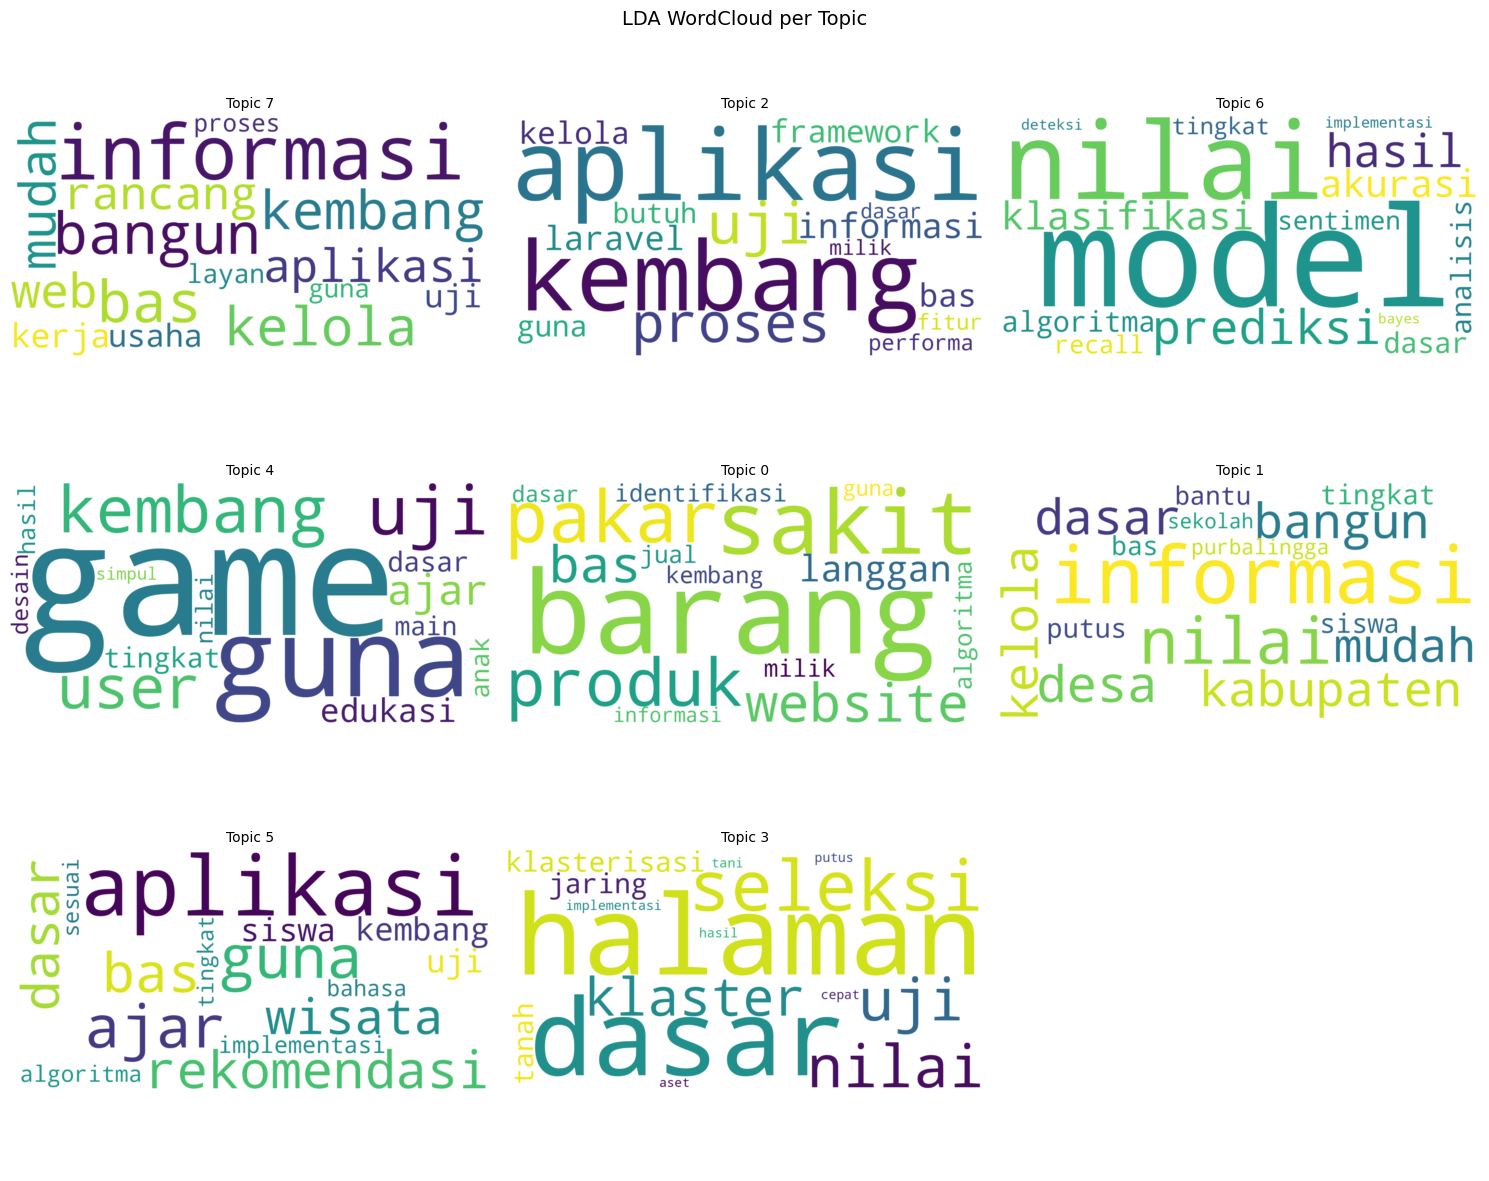


=== Perbandingan Metrik ===


,model,scenario_id,coherence_cv,topic_diversity,num_topics
0,BERTopic,bertopic_017,0.5182,0.8455,11
1,LDA,lda_004,0.3583,0.6500,8


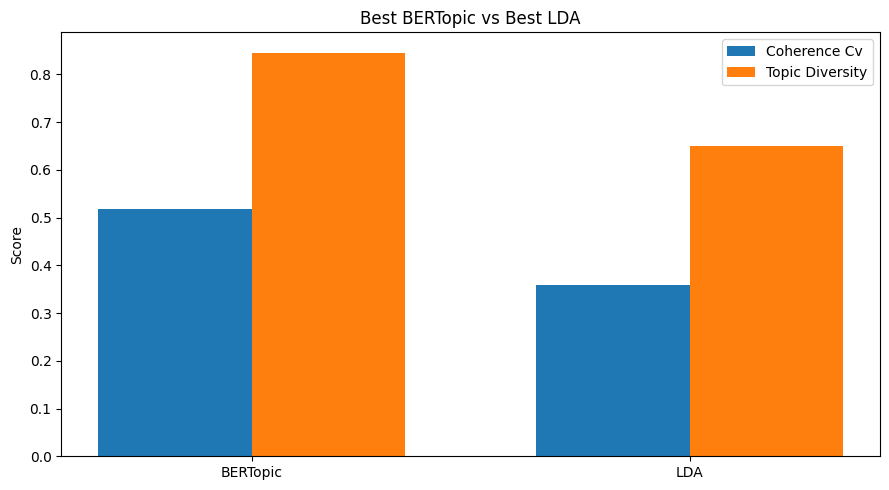

In [8]:
# ============================================================
# 7. Visualisasi
# ============================================================

def plot_wordcloud_grid(payloads, title, max_topics=8, cols=3):
    if WordCloud is None:
        print(f"{title}: wordcloud package not available"); return
    valid = [p for p in payloads[:max_topics] if p.get("freq")]
    if not valid: return
    n = len(valid)
    cols = max(1, min(cols, n))
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, p in zip(axes, valid):
        wc = WordCloud(width=1400, height=700, background_color="white",
                       colormap="viridis", max_words=200).generate_from_frequencies(p["freq"])
        ax.imshow(wc, interpolation="bilinear"); ax.set_title(p["title"], fontsize=10); ax.axis("off")
    for ax in axes[n:]: ax.axis("off")
    fig.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()

# --- BERTopic ---
print("=== BERTopic ===")
if final_bertopic:
    bm = final_bertopic["trainer"].model
    bi = bm.get_topic_info()
    bi = bi[bi["Topic"] != -1].copy()
    if not bi.empty:
        display(bi[["Topic", "Count", "Name"]].head(15))
        top = bi.sort_values("Count", ascending=False).head(15).sort_values("Count")
        plt.figure(figsize=(10, 6))
        plt.barh(top["Topic"].astype(str), top["Count"], color="#1f77b4")
        plt.title("BERTopic: Distribusi Dokumen per Topik"); plt.xlabel("Jumlah Dokumen"); plt.tight_layout(); plt.show()

        wc_ids = bi.sort_values("Count", ascending=False)["Topic"].astype(int).head(8).tolist()
        wc_data = [{"title": f"Topic {t}", "freq": {w: float(s) for w, s in (bm.get_topic(t) or [])[:15] if float(s) > 0}}
                   for t in wc_ids]
        plot_wordcloud_grid(wc_data, "BERTopic WordCloud per Topic")

# --- LDA ---
print("\n=== LDA ===")
if final_lda:
    lm = final_lda["trainer"].model
    bows = [final_lda["trainer"].dictionary.doc2bow(str(d).split()) for d in lda_docs]
    dom = [int(max(lm.get_document_topics(b, minimum_probability=0.0), key=lambda x: x[1])[0])
           for b in bows if b]
    tc = Counter(dom)
    lda_count = pd.DataFrame({"topic_id": list(tc.keys()), "doc_count": list(tc.values())}).sort_values("doc_count", ascending=False)
    plt.figure(figsize=(10, 6))
    plt.bar(lda_count["topic_id"].astype(str), lda_count["doc_count"], color="#ff7f0e")
    plt.title("LDA: Distribusi Dokumen per Topik"); plt.xlabel("Topic ID"); plt.tight_layout(); plt.show()

    wc_ids = lda_count["topic_id"].astype(int).head(8).tolist()
    wc_data = [{"title": f"Topic {t}", "freq": {w: float(s) for w, s in lm.show_topic(t, topn=15) if float(s) > 0}}
               for t in wc_ids]
    plot_wordcloud_grid(wc_data, "LDA WordCloud per Topic")

# --- Comparison ---
print("\n=== Perbandingan Metrik ===")
if not final_metrics.empty:
    display(final_metrics)
    x = np.arange(len(final_metrics)); w = 0.35
    plt.figure(figsize=(9, 5))
    plt.bar(x - w/2, pd.to_numeric(final_metrics["coherence_cv"]), width=w, label="Coherence Cv")
    plt.bar(x + w/2, pd.to_numeric(final_metrics["topic_diversity"]), width=w, label="Topic Diversity")
    plt.xticks(x, final_metrics["model"].tolist()); plt.ylabel("Score")
    plt.title("Best BERTopic vs Best LDA"); plt.legend(); plt.tight_layout(); plt.show()

## 8. Dynamic Topic Analysis (DTA)

Klasifikasi tren menggunakan **relative slope** dari regresi linear:

$$\text{relative\_slope} = \frac{\text{slope}}{\max(\bar{y}, 1.0)}$$

Threshold: `DTA_TREND_THRESHOLD = 0.10`

| Status | Kondisi |
|--------|---------|
| ↑ Emerging | relative_slope ≥ 0.10 **DAN** freq_akhir ≥ freq_awal |
| ↓ Declining | relative_slope ≤ −0.10 **DAN** freq_akhir ≤ freq_awal |
| → Stable | lainnya, atau data < 3 titik |

9it [03:38, 24.30s/it]

📊 Ringkasan Tren DTA:


,trend,n_topics
0,declining,3
1,emerging,5
2,stable,3


,topic_id,trend,n_periods,start_freq,end_freq,slope,relative_slope,top10_keywords
0,2,declining,9,12.0,1.0,-1.133333,-0.159375,"penjualan, transaksi, sampah, waterfall, berba..."
1,0,declining,9,14.0,1.0,-1.866667,-0.200000,"desa, berbasis web, umkm, rancang bangun, meng..."
2,9,declining,6,3.0,1.0,-0.628571,-0.209524,"pmks, berbasis web, banjarnegara, rancang bang..."
3,8,emerging,6,2.0,9.0,1.628571,0.390857,"produk, clustering, penjualan, rekomendasi, na..."
4,6,emerging,5,1.0,7.0,1.600000,0.333333,"edukasi, siswa, pembelajaran, permainan, devel..."
5,3,emerging,5,3.0,3.0,1.700000,0.293103,"performa, laravel, server, beban, throughput, ..."
6,7,emerging,8,1.0,4.0,0.928571,0.247619,"klasterisasi, klasifikasi, umkm, hama, algorit..."
7,4,emerging,9,1.0,3.0,1.400000,0.229091,"deteksi, cnn, performa, precision, diagnosis, ..."
8,1,stable,9,7.0,6.0,0.733333,0.073333,"unsoed, perancangan, audit, laporan, monitorin..."
9,5,stable,8,7.0,2.0,0.142857,0.033613,"pendukung keputusan, penilaian, kriteria, simp..."


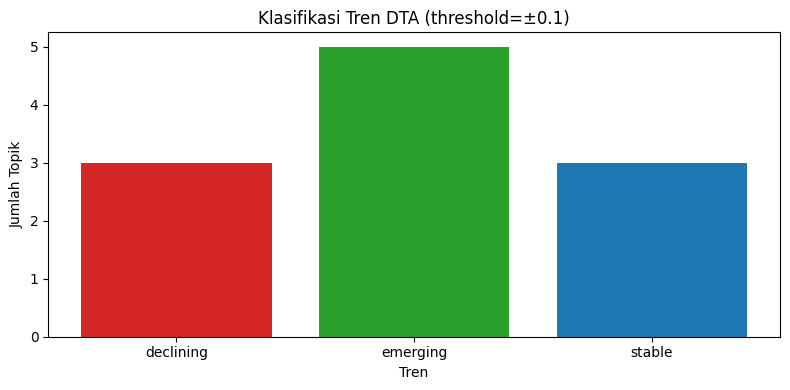

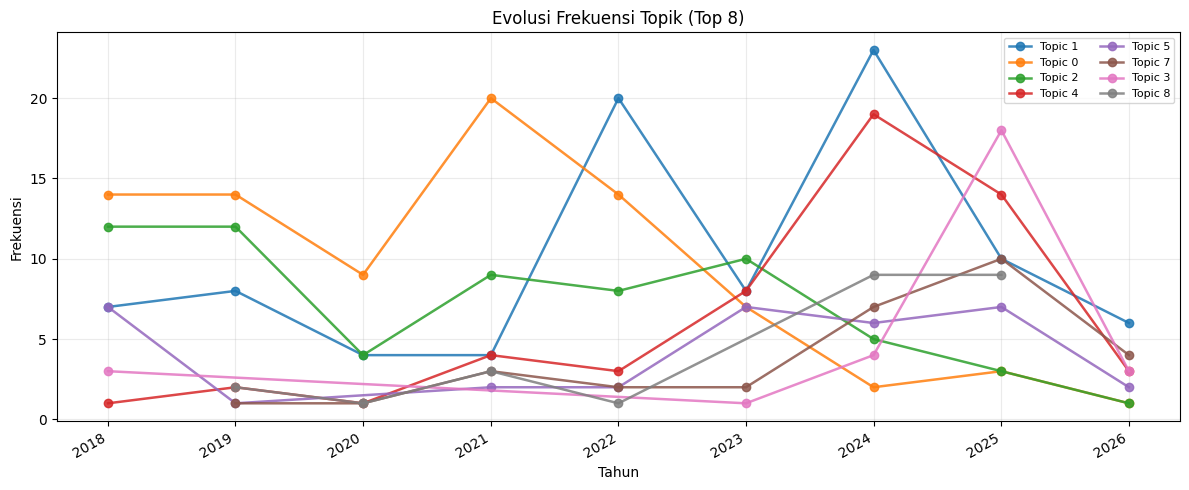


📁 DTA Artifacts:
  - /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-220200/dta_topics_over_time.csv
  - /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-220200/dta_trend_classification.csv


In [9]:
# ============================================================
# 8. Dynamic Topic Analysis (DTA)
# ============================================================

dta_artifacts = []

if final_bertopic is None or timestamps is None:
    print("DTA dilewati: model atau timestamps tidak tersedia.")
else:
    dta_model = final_bertopic["trainer"].model
    time_index = pd.to_datetime(
        pd.Series(timestamps).astype(int).astype(str) + "-01-01", errors="coerce"
    )

    if time_index.isna().any():
        print("DTA dilewati: ada timestamp tidak valid.")
    else:
        try:
            # Topics over time
            dta_df = dta_model.topics_over_time(
                bertopic_docs, timestamps=time_index.tolist()
            )
            dta_df = dta_df.sort_values(["Topic", "Timestamp"]).reset_index(drop=True)
            p1 = RUN_DIR / "dta_topics_over_time.csv"
            dta_df.to_csv(p1, index=False)
            dta_artifacts.append(p1)

            # --- Klasifikasi Tren ---
            work = dta_df.copy()
            work["Topic"] = pd.to_numeric(work["Topic"], errors="coerce").astype(int)
            work = work[work["Topic"] != -1].copy()
            work["Frequency"] = pd.to_numeric(work["Frequency"], errors="coerce").fillna(0)

            trend_rows = []
            for tid, g in work.groupby("Topic"):
                g = g.sort_values("Timestamp")
                y = g["Frequency"].to_numpy(dtype=float)
                n = len(g)

                if n < DTA_MIN_POINTS:
                    label, slope, rel_slope = "stable", np.nan, np.nan
                else:
                    x = np.arange(n, dtype=float)
                    slope = float(np.polyfit(x, y, 1)[0])
                    baseline = max(float(np.mean(y)), 1.0)
                    rel_slope = float(slope / baseline)

                    if rel_slope >= DTA_TREND_THRESHOLD and y[-1] >= y[0]:
                        label = "emerging"
                    elif rel_slope <= -DTA_TREND_THRESHOLD and y[-1] <= y[0]:
                        label = "declining"
                    else:
                        label = "stable"

                keywords = ", ".join([w for w, _ in (dta_model.get_topic(int(tid)) or [])[:10]])
                trend_rows.append({
                    "topic_id": int(tid),
                    "trend": label,
                    "n_periods": n,
                    "start_freq": float(y[0]) if n else np.nan,
                    "end_freq": float(y[-1]) if n else np.nan,
                    "slope": round(slope, 6) if not np.isnan(slope) else np.nan,
                    "relative_slope": round(rel_slope, 6) if not np.isnan(rel_slope) else np.nan,
                    "top10_keywords": keywords,
                })

            trend_df = pd.DataFrame(trend_rows)
            trend_df = trend_df.sort_values(
                ["trend", "relative_slope"], ascending=[True, False]
            ).reset_index(drop=True)

            p2 = RUN_DIR / "dta_trend_classification.csv"
            trend_df.to_csv(p2, index=False)
            dta_artifacts.append(p2)

            # --- Display ---
            print("📊 Ringkasan Tren DTA:")
            summary = trend_df.groupby("trend").size().reset_index(name="n_topics")
            display(summary)
            print()
            display(trend_df)

            # Trend bar chart
            cmap = {"emerging": "#2ca02c", "stable": "#1f77b4", "declining": "#d62728"}
            colors = [cmap.get(v, "#7f7f7f") for v in summary["trend"]]
            plt.figure(figsize=(8, 4))
            plt.bar(summary["trend"], summary["n_topics"], color=colors)
            plt.title(f"Klasifikasi Tren DTA (threshold=±{DTA_TREND_THRESHOLD})")
            plt.xlabel("Tren"); plt.ylabel("Jumlah Topik"); plt.tight_layout(); plt.show()

            # Line chart top 8
            top8 = (work.groupby("Topic")["Frequency"].sum()
                    .sort_values(ascending=False).head(8).index.tolist())
            plt.figure(figsize=(12, 5))
            for tid in top8:
                g = work[work["Topic"] == tid].sort_values("Timestamp")
                plt.plot(pd.to_datetime(g["Timestamp"]), g["Frequency"],
                         marker="o", linewidth=1.8, alpha=0.85, label=f"Topic {tid}")
            plt.title("Evolusi Frekuensi Topik (Top 8)")
            plt.xlabel("Tahun"); plt.ylabel("Frekuensi")
            plt.xticks(rotation=30, ha="right"); plt.grid(alpha=0.25)
            plt.legend(loc="best", ncol=2, fontsize=8); plt.tight_layout(); plt.show()

        except Exception as e:
            print(f"❌ DTA gagal: {e}")

if dta_artifacts:
    print("\n📁 DTA Artifacts:")
    for p in dta_artifacts: print(f"  - {p}")

In [10]:
# ============================================================
# 9. Ringkasan Artefak
# ============================================================

artifact_rows = []
for p in sorted(RUN_DIR.glob("*")):
    if p.is_file():
        artifact_rows.append({"file": p.name, "size_kb": round(p.stat().st_size / 1024.0, 2)})

artifact_df = pd.DataFrame(artifact_rows).sort_values("file").reset_index(drop=True)
print(f"📁 Artifact directory: {RUN_DIR}")
print(f"📊 Total files: {len(artifact_df)}")
display(artifact_df)

print("\n✅ Notebook selesai.")
print(f"Formula scoring: S = {SCORE_WEIGHT_CV}×Cv + {SCORE_WEIGHT_TD}×TD (unified)")
print(f"DTA threshold: ±{DTA_TREND_THRESHOLD}")
print(f"Composite weights: objective={W_OBJECTIVE}, coherence={W_COHERENCE}, diversity={W_DIVERSITY}, efficiency={W_EFFICIENCY}")

📁 Artifact directory: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-220200
📊 Total files: 13


,file,size_kb
0,bertopic_topic_keywords.csv,3.90
1,bertopic_tuning_results.csv,24.85
2,best_config.json,2.30
3,best_retrain_metrics.csv,0.12
4,dta_topics_over_time.csv,6.01
5,dta_trend_classification.csv,1.74
6,lda_topic_keywords.csv,3.28
7,lda_tuning_results.csv,5.47
8,leaderboard_composite.csv,6.22
9,preprocessing_before_after.csv,1629.13



✅ Notebook selesai.
Formula scoring: S = 0.65×Cv + 0.35×TD (unified)
DTA threshold: ±0.1
Composite weights: objective=0.45, coherence=0.3, diversity=0.2, efficiency=0.05
